In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import seaborn as sns
import random


In [2]:
stn = 1
chn = 25

In [3]:
fn = f"traces_station{stn}_channel{chn}_pol{chn%2}.dat"
data = pd.read_csv("traces_127417834/"+fn, delimiter="\t")

In [4]:
modified = pd.concat([data.columns.to_frame().T, data]).reset_index(drop=True).iloc[:,0].str.split(expand=True).astype(float)
modified

,0,1
0,0.0,-5.969695e-10
1,5.0,-3.357519e-10
2,10.0,1.921449e-09
3,15.0,8.477217e-10
4,20.0,-4.329742e-09
...,...,...
65531,327655.0,1.541678e-09
65532,327660.0,1.189878e-09
65533,327665.0,-4.887822e-09
65534,327670.0,2.009925e-10


In [12]:
new = modified.values[8000:-8000].T

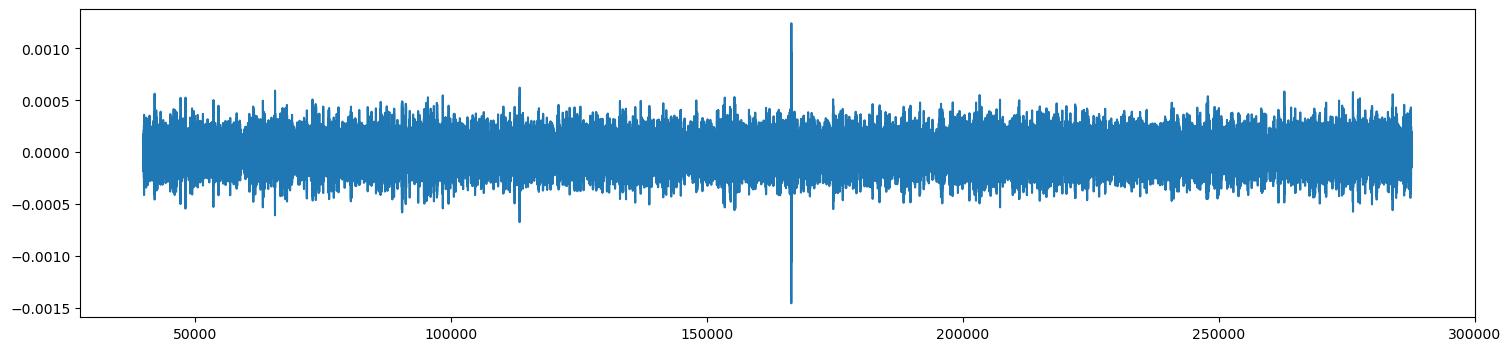

In [14]:
plt.figure(figsize=(18,4))
plt.plot(new[0], new[1])
plt.show()

In [27]:
np.empty((3, *new.shape))

array([[[             nan, -8.85459467e-112, -6.74321858e-153, ...,
          0.00000000e+000,  0.00000000e+000,  0.00000000e+000],
        [ 0.00000000e+000,  0.00000000e+000,  0.00000000e+000, ...,
          0.00000000e+000,  0.00000000e+000,  0.00000000e+000]],

       [[ 0.00000000e+000,  0.00000000e+000,  0.00000000e+000, ...,
          0.00000000e+000,  0.00000000e+000,  0.00000000e+000],
        [ 0.00000000e+000,  0.00000000e+000,  0.00000000e+000, ...,
          0.00000000e+000,  0.00000000e+000,  0.00000000e+000]],

       [[ 0.00000000e+000,  0.00000000e+000,  0.00000000e+000, ...,
          0.00000000e+000,  0.00000000e+000,  0.00000000e+000],
        [ 0.00000000e+000,  0.00000000e+000,  0.00000000e+000, ...,
          0.00000000e+000,  0.00000000e+000,  0.00000000e+000]]],
      shape=(3, 2, 49536))

In [5]:
time = modified.values[:,0]
trace = modified.values[:,1]

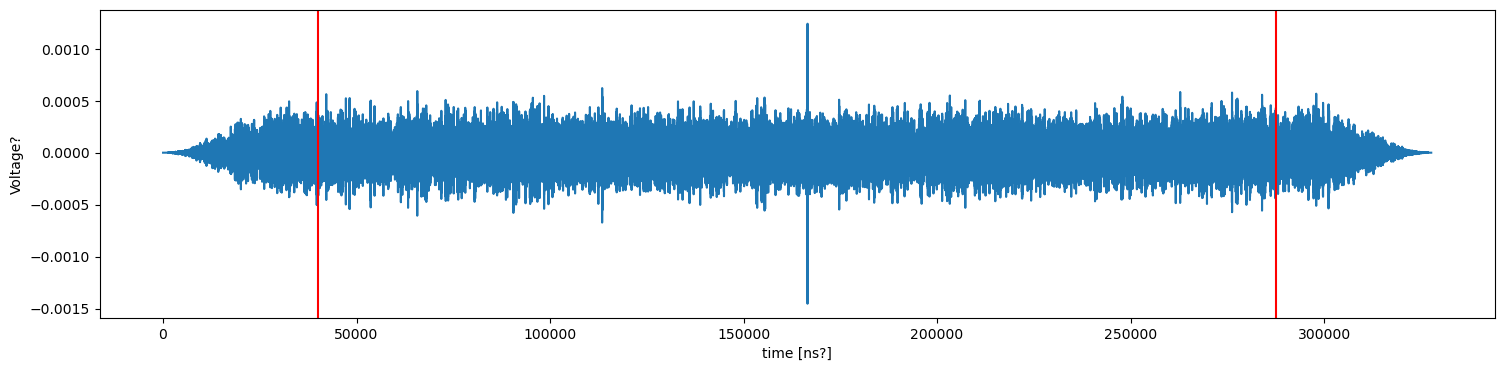

In [8]:
plt.figure(figsize = (18,4))
plt.xlabel("time [ns?]")
plt.ylabel("Voltage?")
plt.plot(time, trace)
plt.axvline(x=40000, c="r")
plt.axvline(x=5*len(time)-40000, c="r")
plt.show()

I need to compare 1D plots 
So I need covariance matrices of the ones I want to compare

RemoveSig2 returns --> full trace, covariance matrix, plot of matrix, zoomed in, 1D plot
it can change <-- Name of the file, output folder, trim, duration, sigwindow

1. Make a reduced RemoveSig2.py that returns covariance matrix and plot of matrix, zoomed in and 1D plot (a lot to store) and write another pipeline that compares 1D
2. 1 but only returns matrix
3. make a pipeline that takes multiple files and compare them (input: Name of the file, output folder, trim, duration, sigwindow, number of files to compare.
Output: Big plot with all the cov matrices, big plot with all 1D, and overlaped plot)

# Random Comparison

In [39]:
def remove_signal(trace, sig_window):
    sig = np.argmax(trace)
    return np.delete(trace, np.arange(sig-sig_window,sig+sig_window+1))

def get_reals(trace, dur):
    to_consider = trace[:-(len(trace)%dur)]
    return np.split(to_consider, len(to_consider)/dur)

def make_cov(trace, duration, sig_window):
    new_trace = remove_signal(trace, sig_window)
    reals = np.array(get_reals(new_trace, duration))
    N = len(reals)

    if N==0:
        return np.zeros((duration, duration)), N

    return np.cov(reals.T), N

 

In [30]:
def get_random_channel(size):
    #87, 87, 85, 87, 87, 85
    stns = []
    chns = []
    for i in range(size):
        stn = int(6*random.random())
        stns.append(stn)
        if stn in (2,5):
            chns.append(int(86*random.random()))
        else:
            chns.append(int(88*random.random()))

    return stns, chns

In [31]:
def modify_data(data, trim):
    modified = pd.concat([data.columns.to_frame().T, data]).reset_index(drop=True).iloc[:,0].str.split(expand=True).astype(float)
    return modified.values[trim:-trim].T
    

In [63]:
def read_files(size, foldername, trim):
    stns, chns = get_random_channel(size)

    for i in range(size):
        fn = f"traces_station{stns[i]}_channel{chns[i]}_pol{chns[i]%2}.dat"
        data = pd.read_csv(foldername+"/"+fn, delimiter="\t")
        modified = modify_data(data, trim)

        if i == 0:
            traces = np.empty((size, *modified.shape))
        
        traces[i] = modified
    
    return traces, stns, chns

In [64]:
traces, stns, chns = read_files(10, "traces_127417834", 8000)

In [65]:
def get_covs(traces, size, dur, sig_window, dirname):
    covs = [None]*size

    # dircovname = os.path.join(dirname, "Covs")
    # if os.path.exists(dircovname) == False:
    #     os.mkdir(dircovname)

    for j in range(size):
        cov, N = make_cov(traces[j,1], dur, sig_window)
        covs[j] = cov

        # cov_name = f"Cov_{dur}.npy"
        # fn_cov = os.path.join(dircovname, cov_name)
        # np.save(fn_cov, cov)
    
    return covs, N

In [66]:
covs, N = get_covs(traces, 10, 200, 20, "yeah")

In [81]:
def draw_cov(covs, size, N, dur, stns, chns):
    rownum = size//3+1
    fig, axes = plt.subplots(nrows=rownum, ncols=3, figsize=(12, 3*rownum))

    axes = np.atleast_2d(axes)

    for j in range(rownum*3):
        row = j//3
        col = j%3

        if j < size:
            sns.heatmap(covs[j], xticklabels=False, yticklabels=False, ax=axes[row, col], square=True, cmap="bwr", norm=colors.CenteredNorm())
            axes[row, col].set_title(f"{stns[j]}-{chns[j]}")
        else:
            axes[row, col].set_visible(False)
    
    plt.suptitle(f"Size: {dur} ({dur*5} ns), {N} realizations")
    plt.tight_layout()
    plt.show()

    # fn = os.path.join(dirname, "cov.png")
    # plt.savefig(fn, dpi=300, bbox_inches='tight')
    # fn = os.path.join(dirname, "cov.pdf")
    # plt.savefig(fn, format="pdf")
    # plt.close()

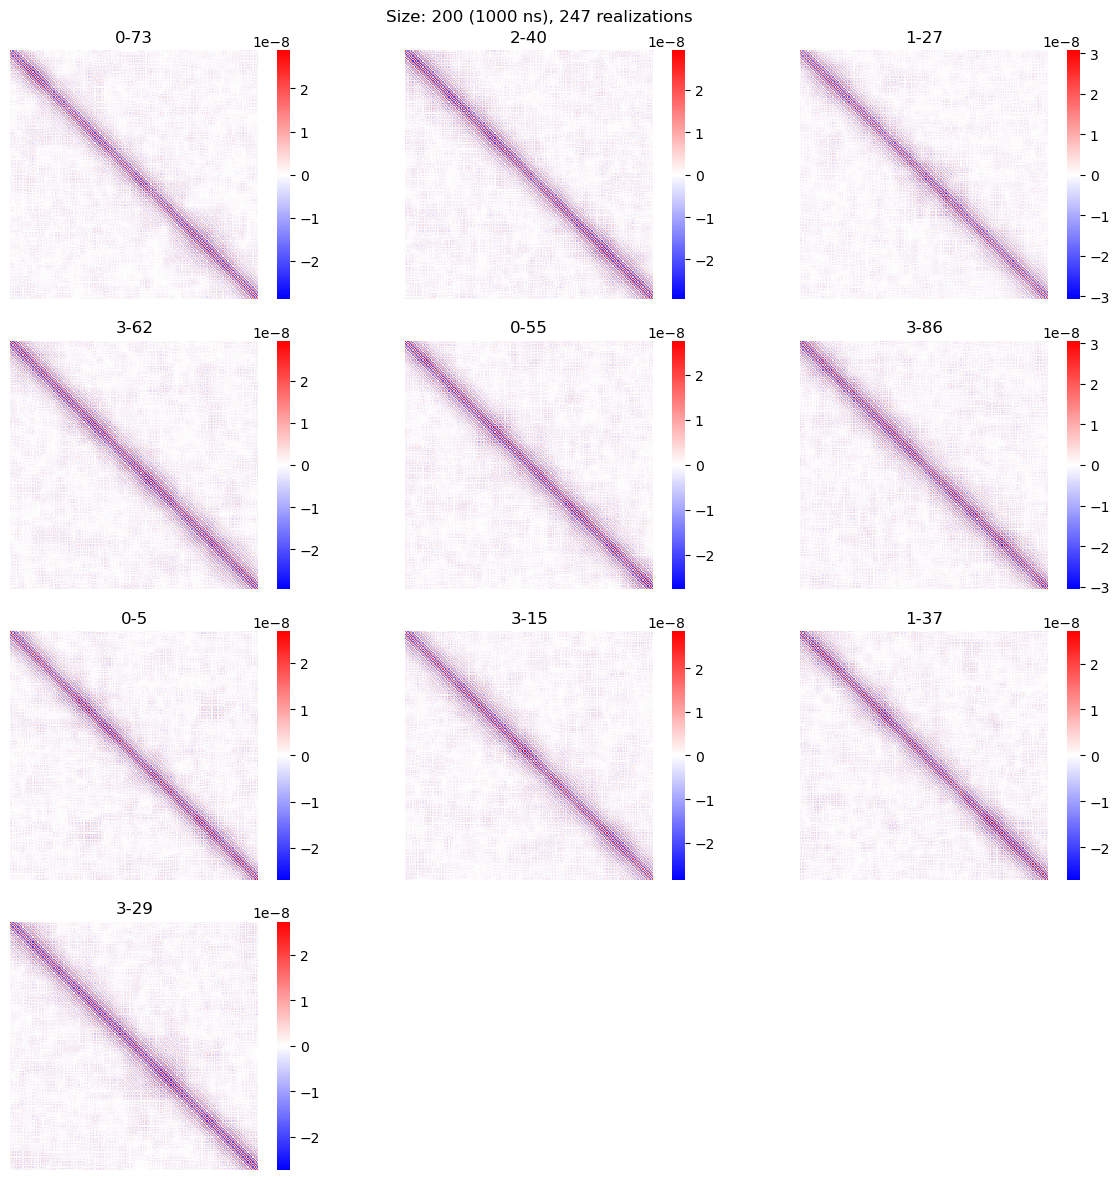

In [82]:
draw_cov(covs, 10, N, 200, stns, chns)

In [110]:
def draw_1D(covs, size, time, dur, stns, chns):
    rownum = size//3+1
    fig, axes = plt.subplots(nrows=rownum, ncols=3, figsize=(12, 3*rownum), sharex=True, sharey=True)

    axes = np.atleast_2d(axes)

    for j in range(rownum*3):
        row = j//3
        col = j%3

        if row == rownum-1:
            axes[row, col].set_xlabel(r"$\Delta t_{i,j}$ [ns]")
        if col == 0:
            axes[row, col].set_ylabel(r"Cov($\Delta t_{i,j}$)")

        if j < size:
            axes[row, col].plot(time[:50], covs[j][0,:50])
            axes[row, col].scatter(time[:50], covs[j][0,:50], marker=".")
            axes[row, col].set_title(f"{stns[j]}-{chns[j]}")
        else:
            axes[row, col].set_visible(False)
            axes[row-1, col].set_xlabel(r"$\Delta t_{i,j}$ [ns]")
            axes[row-1, col].tick_params(labelbottom=True)
    
    plt.suptitle(f"1D function of the first row. Size: {dur} ({dur*5} ns), {N} realizations")
    plt.tight_layout()
    plt.show()
    # fn = os.path.join(dirname, "1d.pdf")
    # plt.savefig(fn, format="pdf")
    # plt.close()

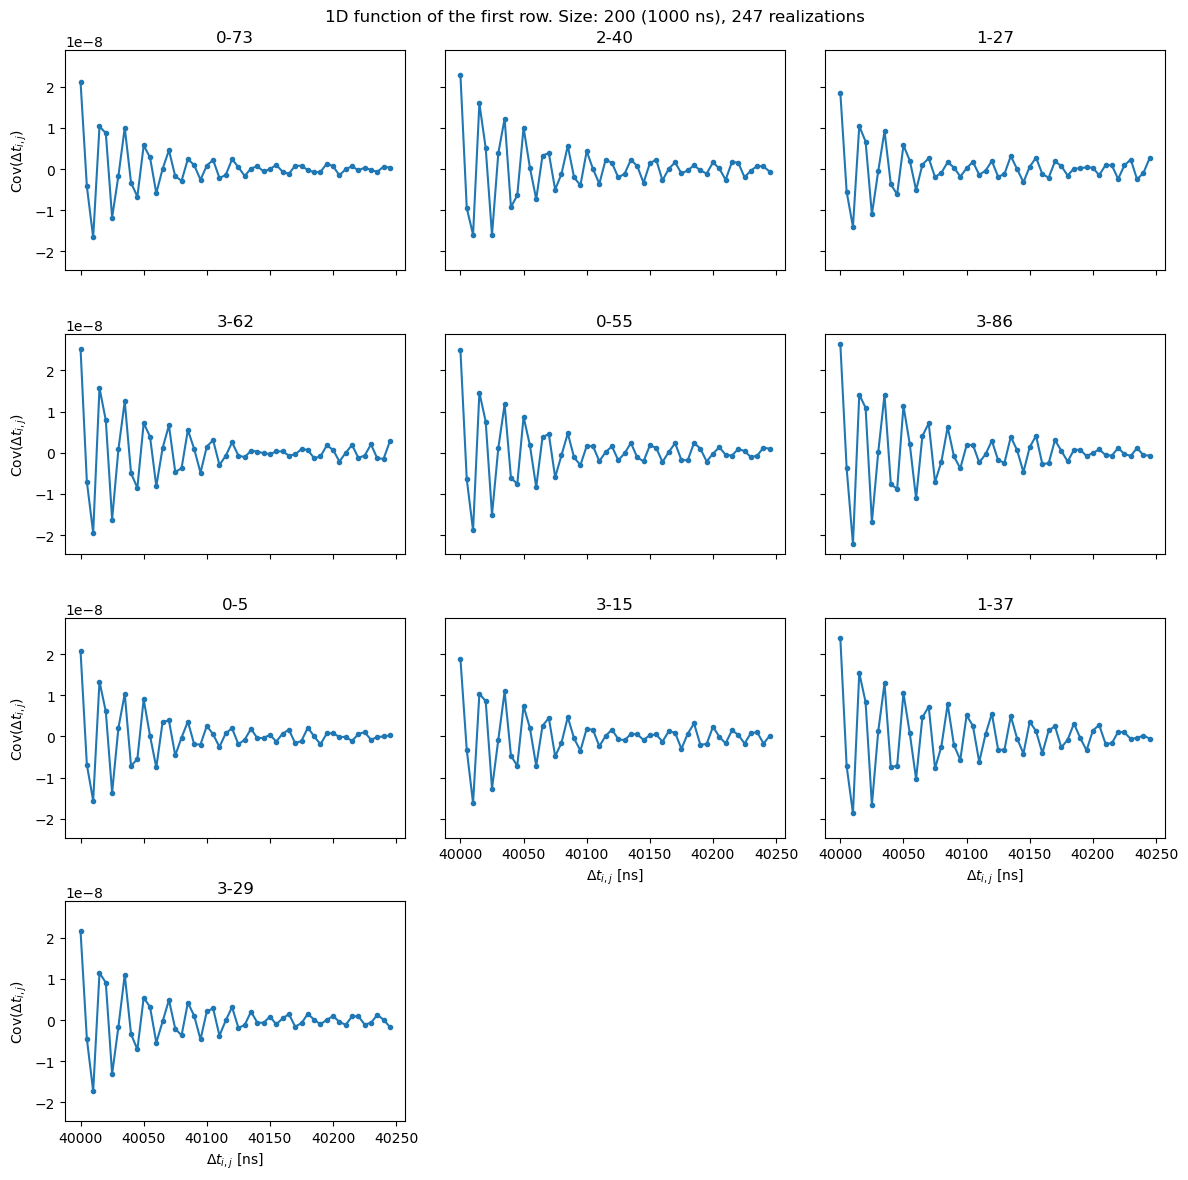

In [111]:
time = traces[0,0]
draw_1D(covs, 10, time, 200, stns, chns)

In [121]:
def overplot_1D(covs, size, time, dur, stns, chns):
    plt.figure(figsize=(12, 8))
    for i in range(50):
        plt.axvline(x=time[i], color="lightgray", linestyle="--")
    plt.axhline(y=0, color="lightgray")
    for j in range(size):
        plt.plot(time[:50], covs[j][0,:50], label=f"{stns[j]}-{chns[j]}")
        plt.scatter(time[:50], covs[j][0,:50], marker=".")
    plt.legend()
    plt.title(f"Overplotting 1D functions (size: {dur}, {size} antennas)")
    plt.show()


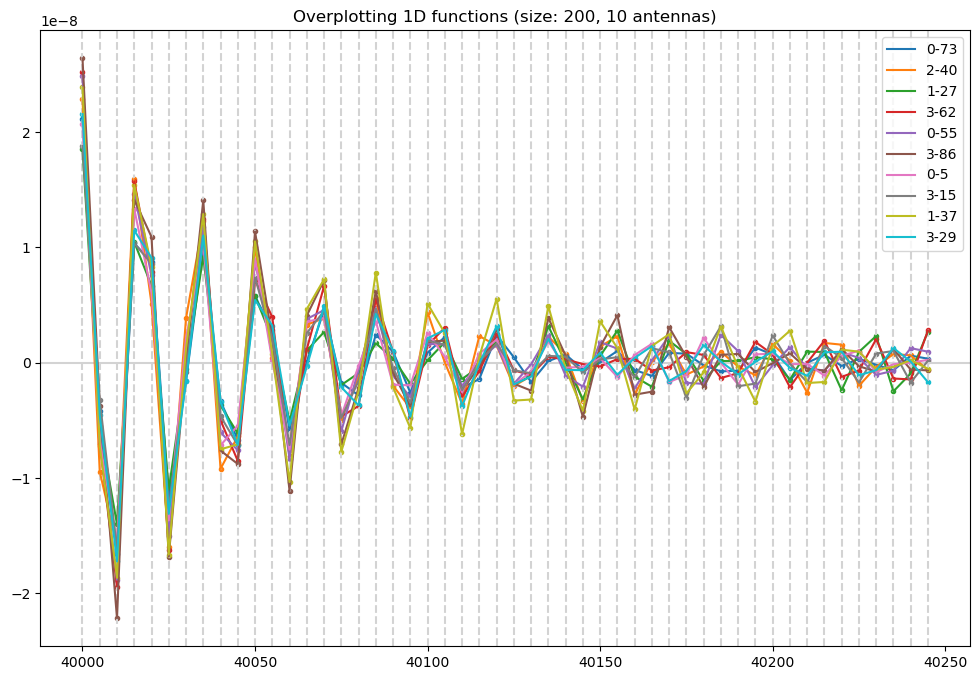

In [122]:
overplot_1D(covs, 10, time, 200, stns, chns)